In [88]:
# Install if needed
#pip install rdflib
#pip install networkx

In [89]:
# Import von rdflib, networkx und andere libraries
from rdflib import Graph, Namespace, RDF
import networkx as nx
from collections import deque
import matplotlib.pyplot as plt

In [90]:
# === 4. BFS with class filtering ===
def bfs_with_class_filter(G, start_node, target_class_uri):
    visited = set()
    queue = deque([start_node])
    matched_nodes = []

    while queue:
        node = queue.popleft()
        if node in visited:
            continue
        visited.add(node)

        if G.nodes[node].get('class') == target_class_uri:
            matched_nodes.append(node)

        for neighbor in G.neighbors(node):
            if neighbor not in visited:
                queue.append(neighbor)

    return matched_nodes

In [91]:
# Gerichtete Graph erstellen
def graph_from_rdf(g):
    
    G = nx.DiGraph()
    
    # Extract rdf:type information
    types = {}
    for s, p, o in g:
        if p == RDF.type:
            types[str(s)] = str(o)
    
    # Add all triples except rdf:type as edges
    for s, p, o in g:
        s_str, o_str, p_str = str(s), str(o), str(p)
        G.add_edge(s_str, o_str, label=p_str)
    
    # Add node classes as attributes
    for node in G.nodes:
        G.nodes[node]['class'] = types.get(node, None)

    # === 3. Show the entire KG ===
    print("Knowledge Graph:")
    for u, v, d in G.edges(data=True):
        label = d['label'].split("/")[-1]
        print(f"{u.split('/')[-1]} --[{label}]--> {v.split('/')[-1]}")

    
    return G

In [92]:
# SCHRITT 1

g = Graph()

# Namespace definieren
SC = Namespace("http://example.org/")

# Triples
g.add((SC.supplyChain1, RDF.type, SC.supplyChain))
g.add((SC.produktion, SC.istTeilVon, SC.hersteller))

g.add((SC.teilzulieferer, SC.istTeilVon, SC.supplyChain1))
g.add((SC.teilzulieferer, RDF.type, SC.firma))

g.add((SC.hersteller, SC.istTeilVon, SC.supplyChain1))
g.add((SC.hersteller, RDF.type, SC.firma))

g.add((SC.einzelhändler1, SC.istTeilVon, SC.supplyChain1))
g.add((SC.einzelhändler1, RDF.type, SC.firma))
g.add((SC.einzelhändler2, SC.istTeilVon, SC.supplyChain1))
g.add((SC.einzelhändler2, RDF.type, SC.firma))

g.add((SC.Bestand, SC.istTeilVon, SC.teilzulieferer))
g.add((SC.hersteller, RDF.type, SC.ValueStream))

g.add((SC.Verkauf1, SC.istTeilVon, SC.einzelhändler1))
g.add((SC.Verkauf1, RDF.type, SC.ValueStream))
g.add((SC.Verkauf2, SC.istTeilVon, SC.einzelhändler2))
g.add((SC.Verkauf2, RDF.type, SC.ValueStream))

g.add((SC.VorlaufzeitBestand, SC.istTeilVon, SC.Bestand))
g.add((SC.VorlaufzeitBestand, RDF.type, SC.Vorlaufzeit))

g.add((SC.VorlaufzeitProduktion, SC.istTeilVon, SC.produktion))
g.add((SC.VorlaufzeitProduktion, RDF.type, SC.Vorlaufzeit))

g.add((SC.VorlaufzeitVerkauf1, SC.istTeilVon, SC.Verkauf1))
g.add((SC.VorlaufzeitVerkauf1, RDF.type, SC.Vorlaufzeit))
g.add((SC.VorlaufzeitVerkauf2, SC.istTeilVon, SC.Verkauf2))
g.add((SC.VorlaufzeitVerkauf2, RDF.type, SC.Vorlaufzeit))
g.add((SC.hersteller, RDF.type, SC.firma))
g.add((SC.produktion, RDF.type, SC.ValueStream))

<Graph identifier=Nb3c317365a90401ab638408fd64e1919 (<class 'rdflib.graph.Graph'>)>

In [93]:
# SCHRITT 2

G = graph_from_rdf(g)

Knowledge Graph:
supplyChain1 --[22-rdf-syntax-ns#type]--> supplyChain
Verkauf2 --[22-rdf-syntax-ns#type]--> ValueStream
Verkauf2 --[istTeilVon]--> einzelhändler2
einzelhändler2 --[22-rdf-syntax-ns#type]--> firma
einzelhändler2 --[istTeilVon]--> supplyChain1
einzelhändler1 --[22-rdf-syntax-ns#type]--> firma
einzelhändler1 --[istTeilVon]--> supplyChain1
VorlaufzeitVerkauf1 --[istTeilVon]--> Verkauf1
VorlaufzeitVerkauf1 --[22-rdf-syntax-ns#type]--> Vorlaufzeit
Verkauf1 --[istTeilVon]--> einzelhändler1
Verkauf1 --[22-rdf-syntax-ns#type]--> ValueStream
VorlaufzeitVerkauf2 --[22-rdf-syntax-ns#type]--> Vorlaufzeit
VorlaufzeitVerkauf2 --[istTeilVon]--> Verkauf2
produktion --[22-rdf-syntax-ns#type]--> ValueStream
produktion --[istTeilVon]--> hersteller
hersteller --[istTeilVon]--> supplyChain1
hersteller --[22-rdf-syntax-ns#type]--> firma
hersteller --[22-rdf-syntax-ns#type]--> ValueStream
VorlaufzeitBestand --[22-rdf-syntax-ns#type]--> Vorlaufzeit
VorlaufzeitBestand --[istTeilVon]--> Bestand


In [94]:
# SCHRITT 3 – Vorlaufzeiten mit Zahlenwerten ergänzen

from rdflib import Literal, XSD

# Beispielwerte in Tagen
g.add((SC.VorlaufzeitBestand,     SC.hatWert, Literal(5,  datatype=XSD.integer)))
g.add((SC.VorlaufzeitProduktion,  SC.hatWert, Literal(10, datatype=XSD.integer)))
g.add((SC.VorlaufzeitVerkauf1,    SC.hatWert, Literal(3,  datatype=XSD.integer)))
g.add((SC.VorlaufzeitVerkauf2,    SC.hatWert, Literal(3,  datatype=XSD.integer)))

# Graph neu bauen (mit den neuen hatWert-Triples)
G = graph_from_rdf(g)

# hatWert-Werte aus RDF auslesen
vorlaufzeit_werte = {}
for s, p, o in g:
    if str(p).endswith("hatWert"):
        vorlaufzeit_werte[str(s)] = int(o)

# BFS auf umgekehrtem Graphen – suche alle Vorlaufzeit-Knoten
start_node   = str(SC.supplyChain1)
target_class = str(SC.Vorlaufzeit)

reversed_G = G.reverse()
vz_nodes = bfs_with_class_filter(reversed_G, start_node, target_class)

print("=== BFS Ergebnis (vor Optimierung) ===")
for node in vz_nodes:
    name = node.split("/")[-1]
    wert = vorlaufzeit_werte.get(node, "?")
    print(f"  {name}: {wert} Tage")

gesamtzeit = sum(vorlaufzeit_werte.get(n, 0) for n in vz_nodes)
print(f"\nGesamtlieferzeit: {gesamtzeit} Tage")

Knowledge Graph:
supplyChain1 --[22-rdf-syntax-ns#type]--> supplyChain
Verkauf2 --[22-rdf-syntax-ns#type]--> ValueStream
Verkauf2 --[istTeilVon]--> einzelhändler2
einzelhändler2 --[22-rdf-syntax-ns#type]--> firma
einzelhändler2 --[istTeilVon]--> supplyChain1
einzelhändler1 --[22-rdf-syntax-ns#type]--> firma
einzelhändler1 --[istTeilVon]--> supplyChain1
VorlaufzeitVerkauf1 --[istTeilVon]--> Verkauf1
VorlaufzeitVerkauf1 --[22-rdf-syntax-ns#type]--> Vorlaufzeit
VorlaufzeitVerkauf1 --[hatWert]--> 3
Verkauf1 --[istTeilVon]--> einzelhändler1
Verkauf1 --[22-rdf-syntax-ns#type]--> ValueStream
VorlaufzeitVerkauf2 --[22-rdf-syntax-ns#type]--> Vorlaufzeit
VorlaufzeitVerkauf2 --[istTeilVon]--> Verkauf2
VorlaufzeitVerkauf2 --[hatWert]--> 3
produktion --[22-rdf-syntax-ns#type]--> ValueStream
produktion --[istTeilVon]--> hersteller
VorlaufzeitProduktion --[hatWert]--> 10
VorlaufzeitProduktion --[istTeilVon]--> produktion
VorlaufzeitProduktion --[22-rdf-syntax-ns#type]--> Vorlaufzeit
hersteller --[ist

In [95]:
# SCHRITT 4 – Optimierung: neues Triple für direkten Shortcut

# Problem vorher: supplyChain1 → teilzulieferer → Bestand → VorlaufzeitBestand (3 Hops)
# Lösung: VorlaufzeitBestand direkt mit supplyChain1 verbinden (1 Hop)

g.add((SC.VorlaufzeitBestand,    SC.istTeilVon, SC.supplyChain1))
g.add((SC.VorlaufzeitProduktion, SC.istTeilVon, SC.supplyChain1))
g.add((SC.VorlaufzeitVerkauf1,   SC.istTeilVon, SC.supplyChain1))
g.add((SC.VorlaufzeitVerkauf2,   SC.istTeilVon, SC.supplyChain1))

# Graph neu aufbauen mit Shortcuts
G_opt = graph_from_rdf(g)
reversed_G_opt = G_opt.reverse()

# BFS zählen – wie viele Schritte bis zum ersten Treffer?
def bfs_mit_schritte(G, start, target_class):
    visited = set()
    queue = deque([(start, 0)])  # (node, tiefe)
    ergebnisse = []

    while queue:
        node, tiefe = queue.popleft()
        if node in visited:
            continue
        visited.add(node)

        if G.nodes[node].get('class') == target_class:
            ergebnisse.append((node.split("/")[-1], tiefe))

        for neighbor in G.neighbors(node):
            if neighbor not in visited:
                queue.append((neighbor, tiefe + 1))

    return ergebnisse

print("=== BFS Ergebnis (nach Optimierung) ===")
ergebnisse = bfs_mit_schritte(reversed_G_opt, start_node, target_class)
for name, tiefe in ergebnisse:
    wert = vorlaufzeit_werte.get(str(SC[name]), "?")
    print(f"  {name}: {wert} Tage  (gefunden in Tiefe {tiefe})")

gesamtzeit_opt = sum(vorlaufzeit_werte.get(str(SC[n]), 0) for n, _ in ergebnisse)
print(f"\nGesamtlieferzeit: {gesamtzeit_opt} Tage")

Knowledge Graph:
Verkauf2 --[22-rdf-syntax-ns#type]--> ValueStream
Verkauf2 --[istTeilVon]--> einzelhändler2
VorlaufzeitBestand --[istTeilVon]--> supplyChain1
VorlaufzeitBestand --[22-rdf-syntax-ns#type]--> Vorlaufzeit
VorlaufzeitBestand --[hatWert]--> 5
VorlaufzeitBestand --[istTeilVon]--> Bestand
supplyChain1 --[22-rdf-syntax-ns#type]--> supplyChain
einzelhändler1 --[22-rdf-syntax-ns#type]--> firma
einzelhändler1 --[istTeilVon]--> supplyChain1
VorlaufzeitVerkauf1 --[22-rdf-syntax-ns#type]--> Vorlaufzeit
VorlaufzeitVerkauf1 --[hatWert]--> 3
VorlaufzeitVerkauf1 --[istTeilVon]--> Verkauf1
VorlaufzeitVerkauf1 --[istTeilVon]--> supplyChain1
VorlaufzeitProduktion --[istTeilVon]--> supplyChain1
VorlaufzeitProduktion --[hatWert]--> 10
VorlaufzeitProduktion --[22-rdf-syntax-ns#type]--> Vorlaufzeit
VorlaufzeitProduktion --[istTeilVon]--> produktion
VorlaufzeitVerkauf2 --[22-rdf-syntax-ns#type]--> Vorlaufzeit
VorlaufzeitVerkauf2 --[hatWert]--> 3
VorlaufzeitVerkauf2 --[istTeilVon]--> Verkauf2
Vo

Knowledge Graph:
supplyChain1 --[22-rdf-syntax-ns#type]--> supplyChain
Verkauf2 --[22-rdf-syntax-ns#type]--> ValueStream
Verkauf2 --[istTeilVon]--> einzelhändler2
einzelhändler2 --[22-rdf-syntax-ns#type]--> firma
einzelhändler2 --[istTeilVon]--> supplyChain1
einzelhändler1 --[22-rdf-syntax-ns#type]--> firma
einzelhändler1 --[istTeilVon]--> supplyChain1
VorlaufzeitVerkauf1 --[istTeilVon]--> Verkauf1
VorlaufzeitVerkauf1 --[22-rdf-syntax-ns#type]--> Vorlaufzeit
Verkauf1 --[istTeilVon]--> einzelhändler1
Verkauf1 --[22-rdf-syntax-ns#type]--> ValueStream
VorlaufzeitVerkauf2 --[22-rdf-syntax-ns#type]--> Vorlaufzeit
VorlaufzeitVerkauf2 --[istTeilVon]--> Verkauf2
hersteller --[istTeilVon]--> supplyChain1
hersteller --[22-rdf-syntax-ns#type]--> firma
hersteller --[22-rdf-syntax-ns#type]--> ValueStream
VorlaufzeitBestand --[22-rdf-syntax-ns#type]--> Vorlaufzeit
VorlaufzeitBestand --[istTeilVon]--> Bestand
VorlaufzeitProduktion --[istTeilVon]--> produktion
VorlaufzeitProduktion --[22-rdf-syntax-ns

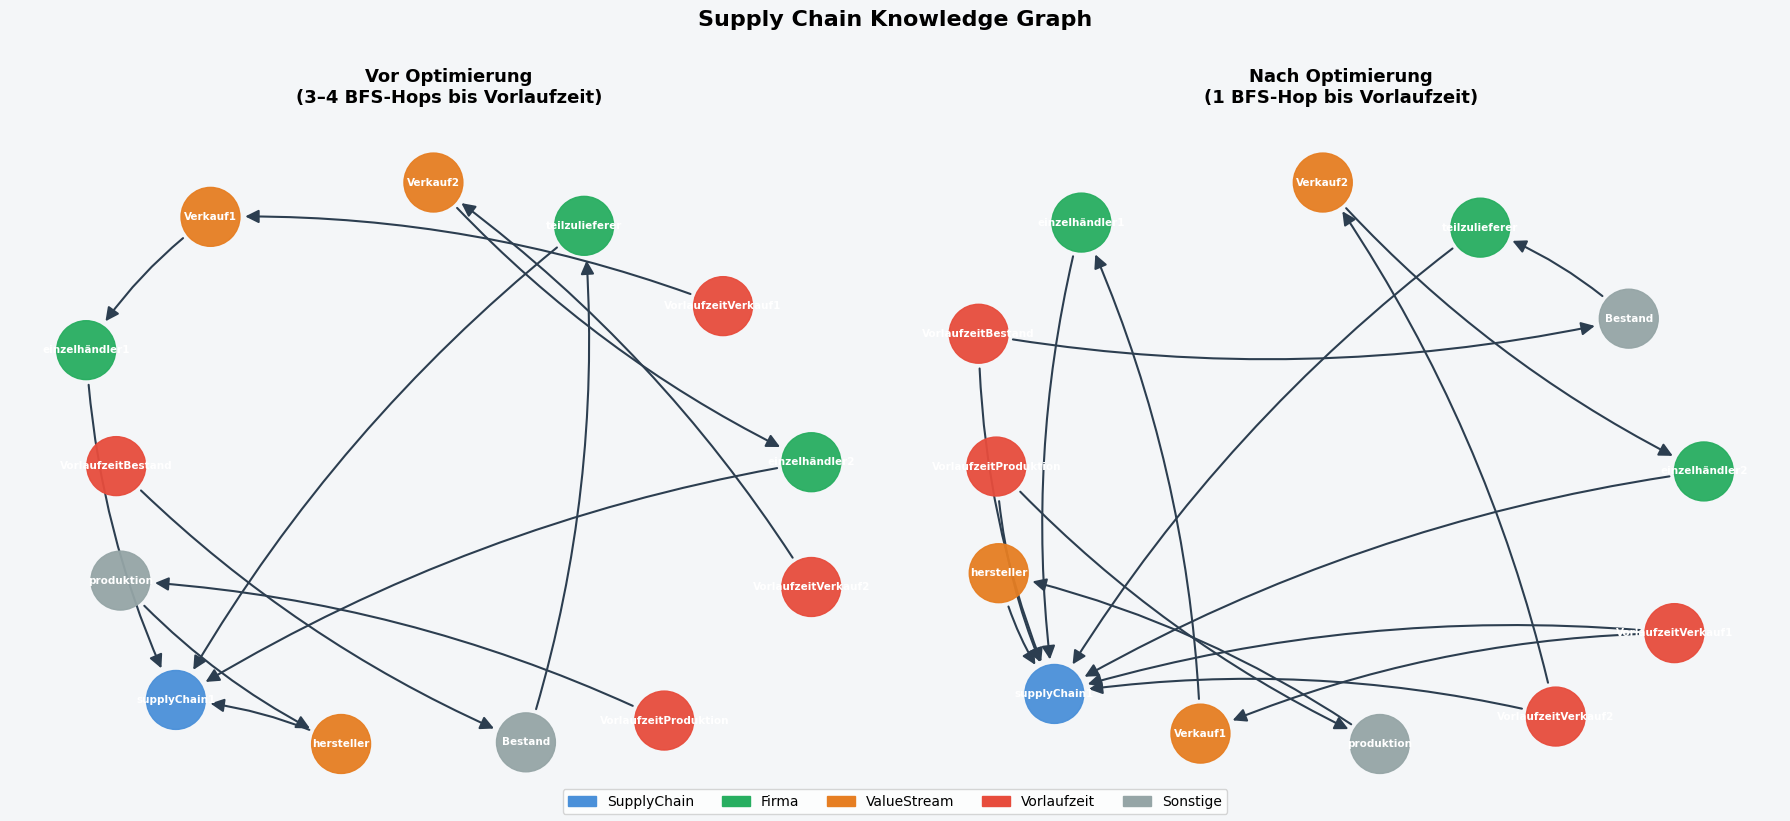

In [96]:
# SCHRITT 5 – Visualisierung vor und nach Optimierung

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# === Farben pro Klasse ===
farben_map = {
    str(SC.supplyChain): "#4A90D9",
    str(SC.firma):       "#27AE60",
    str(SC.ValueStream): "#E67E22",
    str(SC.Vorlaufzeit): "#E74C3C",
    None:                "#95A5A6"
}

def get_farbe(G, node):
    klasse = G.nodes[node].get('class')
    return farben_map.get(klasse, "#95A5A6")

def nur_istTeilVon(G):
    """Gibt einen Graphen zurück, der nur istTeilVon-Kanten enthält."""
    H = nx.DiGraph()
    for u, v, d in G.edges(data=True):
        if "istTeilVon" in d.get('label', ''):
            H.add_edge(u, v)
    for node in G.nodes(data=True):
        H.add_node(node[0], **node[1])
    return H

def zeige_graph(ax, G, titel):
    H = nur_istTeilVon(G)

    # Nur Knoten die verbunden sind
    knoten = [n for n in H.nodes if H.degree(n) > 0]
    H = H.subgraph(knoten).copy()

    # Labels kürzen
    labels = {n: n.split("/")[-1] for n in H.nodes}
    node_colors = [get_farbe(G, n) for n in H.nodes]

    pos = nx.spring_layout(H, seed=42, k=2.5)

    nx.draw_networkx_nodes(H, pos, ax=ax, node_color=node_colors,
                           node_size=1800, alpha=0.95)
    nx.draw_networkx_labels(H, pos, labels=labels, ax=ax,
                            font_size=7.5, font_weight='bold', font_color='white')
    nx.draw_networkx_edges(H, pos, ax=ax, edge_color="#2C3E50",
                           arrows=True, arrowsize=20,
                           connectionstyle="arc3,rad=0.1",
                           width=1.5, min_source_margin=25, min_target_margin=25)
    ax.set_title(titel, fontsize=13, fontweight='bold', pad=15)
    ax.axis('off')

# === Graph VOR Optimierung ===
g_vor = Graph()
SC2 = Namespace("http://example.org/")

g_vor.add((SC2.supplyChain1, RDF.type, SC2.supplyChain))
g_vor.add((SC2.produktion, SC2.istTeilVon, SC2.hersteller))
g_vor.add((SC2.teilzulieferer, SC2.istTeilVon, SC2.supplyChain1))
g_vor.add((SC2.teilzulieferer, RDF.type, SC2.firma))
g_vor.add((SC2.hersteller, SC2.istTeilVon, SC2.supplyChain1))
g_vor.add((SC2.hersteller, RDF.type, SC2.firma))
g_vor.add((SC2.einzelhändler1, SC2.istTeilVon, SC2.supplyChain1))
g_vor.add((SC2.einzelhändler1, RDF.type, SC2.firma))
g_vor.add((SC2.einzelhändler2, SC2.istTeilVon, SC2.supplyChain1))
g_vor.add((SC2.einzelhändler2, RDF.type, SC2.firma))
g_vor.add((SC2.Bestand, SC2.istTeilVon, SC2.teilzulieferer))
g_vor.add((SC2.hersteller, RDF.type, SC2.ValueStream))
g_vor.add((SC2.Verkauf1, SC2.istTeilVon, SC2.einzelhändler1))
g_vor.add((SC2.Verkauf1, RDF.type, SC2.ValueStream))
g_vor.add((SC2.Verkauf2, SC2.istTeilVon, SC2.einzelhändler2))
g_vor.add((SC2.Verkauf2, RDF.type, SC2.ValueStream))
g_vor.add((SC2.VorlaufzeitBestand, SC2.istTeilVon, SC2.Bestand))
g_vor.add((SC2.VorlaufzeitBestand, RDF.type, SC2.Vorlaufzeit))
g_vor.add((SC2.VorlaufzeitProduktion, SC2.istTeilVon, SC2.produktion))
g_vor.add((SC2.VorlaufzeitProduktion, RDF.type, SC2.Vorlaufzeit))
g_vor.add((SC2.VorlaufzeitVerkauf1, SC2.istTeilVon, SC2.Verkauf1))
g_vor.add((SC2.VorlaufzeitVerkauf1, RDF.type, SC2.Vorlaufzeit))
g_vor.add((SC2.VorlaufzeitVerkauf2, SC2.istTeilVon, SC2.Verkauf2))
g_vor.add((SC2.VorlaufzeitVerkauf2, RDF.type, SC2.Vorlaufzeit))

G_vor = graph_from_rdf(g_vor)

# === Graph NACH Optimierung (Shortcuts hinzufügen) ===
import copy
g_nach = copy.deepcopy(g_vor)
g_nach.add((SC2.VorlaufzeitBestand,    SC2.istTeilVon, SC2.supplyChain1))
g_nach.add((SC2.VorlaufzeitProduktion, SC2.istTeilVon, SC2.supplyChain1))
g_nach.add((SC2.VorlaufzeitVerkauf1,   SC2.istTeilVon, SC2.supplyChain1))
g_nach.add((SC2.VorlaufzeitVerkauf2,   SC2.istTeilVon, SC2.supplyChain1))

G_nach = graph_from_rdf(g_nach)

# === Plot ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#F4F6F8')

zeige_graph(ax1, G_vor,  "Vor Optimierung\n(3–4 BFS-Hops bis Vorlaufzeit)")
zeige_graph(ax2, G_nach, "Nach Optimierung\n(1 BFS-Hop bis Vorlaufzeit)")

# Legende
legende = [
    mpatches.Patch(color="#4A90D9", label="SupplyChain"),
    mpatches.Patch(color="#27AE60", label="Firma"),
    mpatches.Patch(color="#E67E22", label="ValueStream"),
    mpatches.Patch(color="#E74C3C", label="Vorlaufzeit"),
    mpatches.Patch(color="#95A5A6", label="Sonstige"),
]
fig.legend(handles=legende, loc='lower center', ncol=5,
           fontsize=10, frameon=True, fancybox=True)

plt.suptitle("Supply Chain Knowledge Graph", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("supply_chain_kg.png", dpi=150, bbox_inches='tight')
plt.show()